## Data Exploration

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
import numpy as np

In [2]:
df = pd.read_csv(
   "../../data/raw/01_square_item_sales_detail_24mo.csv"
)
df.head()

,Date,Time,Time Zone,Category,Item,Qty,Price Point Name,SKU,Unit Price,Gross Sales,...,Tax,Total Collected,Transaction ID,Payment Method,Device Name,Location,Customer ID,Event Type,Unit Cost,Gross Profit
0,2024-01-01,14:41,CST,Home Goods,Ceramic Coffee Mug,1,Regular,SQ-1058,16.0,16.0,...,1.32,17.32,TXN1000001,Card,Register 2,Store 01 - Austin,NaN,Payment,4.48,11.52
1,2024-01-01,15:50,CST,Apparel,Classic Denim Jacket,1,S,SQ-1001,79.0,79.0,...,6.52,85.52,TXN1000002,Card,Register 2,Store 01 - Austin,CUST16654,Payment,35.55,43.45
2,2024-01-01,13:11,CST,Electronics,Wireless Earbuds,1,Black,SQ-1048,79.0,79.0,...,6.52,85.52,TXN1000003,Card,Register 1,Store 01 - Austin,CUST02796,Payment,43.45,35.55
3,2024-01-01,15:33,CST,Apparel,Hooded Sweatshirt,2,M,SQ-1013,45.0,90.0,...,6.31,82.81,TXN1000004,Card,Register 2,Store 01 - Austin,CUST06950,Payment,18.00,40.50
4,2024-01-01,15:33,CST,Footwear,Canvas Sneakers,1,10,SQ-1027,59.0,59.0,...,3.89,51.09,TXN1000004,Card,Register 2,Store 01 - Austin,CUST06950,Payment,28.32,18.88


In [3]:
df.shape

(970838, 22)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970838 entries, 0 to 970837
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Date              970838 non-null  object 
 1   Time              970838 non-null  object 
 2   Time Zone         970838 non-null  object 
 3   Category          970838 non-null  object 
 4   Item              970838 non-null  object 
 5   Qty               970838 non-null  int64  
 6   Price Point Name  970838 non-null  object 
 7   SKU               970838 non-null  object 
 8   Unit Price        970838 non-null  float64
 9   Gross Sales       970838 non-null  float64
 10  Discounts         970838 non-null  float64
 11  Net Sales         970838 non-null  float64
 12  Tax               970838 non-null  float64
 13  Total Collected   970838 non-null  float64
 14  Transaction ID    970838 non-null  object 
 15  Payment Method    970838 non-null  object 
 16  Device Name       97

In [5]:
df.dtypes

Date                 object
Time                 object
Time Zone            object
Category             object
Item                 object
Qty                   int64
Price Point Name     object
SKU                  object
Unit Price          float64
Gross Sales         float64
Discounts           float64
Net Sales           float64
Tax                 float64
Total Collected     float64
Transaction ID       object
Payment Method       object
Device Name          object
Location             object
Customer ID          object
Event Type           object
Unit Cost           float64
Gross Profit        float64
dtype: object

In [6]:
df.duplicated().sum()

0

In [7]:
insights = pd.DataFrame({
    "missing_count": df.isna().sum(),
    'duplicated_count': df.duplicated().sum(),
    
    
})

insights

,missing_count,duplicated_count
Date,0,0
Time,0,0
Time Zone,0,0
Category,0,0
Item,0,0
Qty,0,0
Price Point Name,0,0
SKU,0,0
Unit Price,0,0
Gross Sales,0,0


In [8]:
df.nunique()

Date                   729
Time                   720
Time Zone                1
Category                 6
Item                    32
Qty                      4
Price Point Name        25
SKU                     67
Unit Price              31
Gross Sales            107
Discounts              242
Net Sales              394
Tax                    378
Total Collected        394
Transaction ID      585691
Payment Method           3
Device Name              3
Location                30
Customer ID          19999
Event Type               2
Unit Cost               36
Gross Profit           559
dtype: int64

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Qty,970838.0,1.208354,0.532151,-1.00,1.00,1.00,1.00,3.00
Unit Price,970838.0,41.999111,26.421474,9.50,21.00,35.00,59.00,129.00
Gross Sales,970838.0,50.749456,41.410184,-129.00,22.00,40.00,68.00,387.00
Discounts,970838.0,-2.754659,5.959887,-154.80,-3.50,0.00,0.00,0.00
Net Sales,970838.0,47.994798,39.640906,-129.00,21.00,39.00,60.00,387.00
Tax,970838.0,3.959895,3.270411,-10.64,1.73,3.22,4.95,31.93
Total Collected,970838.0,51.954693,42.911315,-139.64,22.73,42.22,64.95,418.93
Unit Cost,970838.0,17.738910,14.470461,2.66,7.04,12.60,28.32,67.08
Gross Profit,970838.0,26.558557,19.466697,-61.92,13.65,22.40,31.60,185.76


## Data Cleaning

In [10]:
df.drop(columns=["Time Zone"], inplace=True)

In [11]:
df["Date"] = pd.to_datetime(df["Date"])
df["Time"] = pd.to_datetime(df["Time"], format="%H:%M").dt.time

## EDA

In [12]:
categorical_cols = df.select_dtypes(
    include=["object", "category"]
).columns

numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns


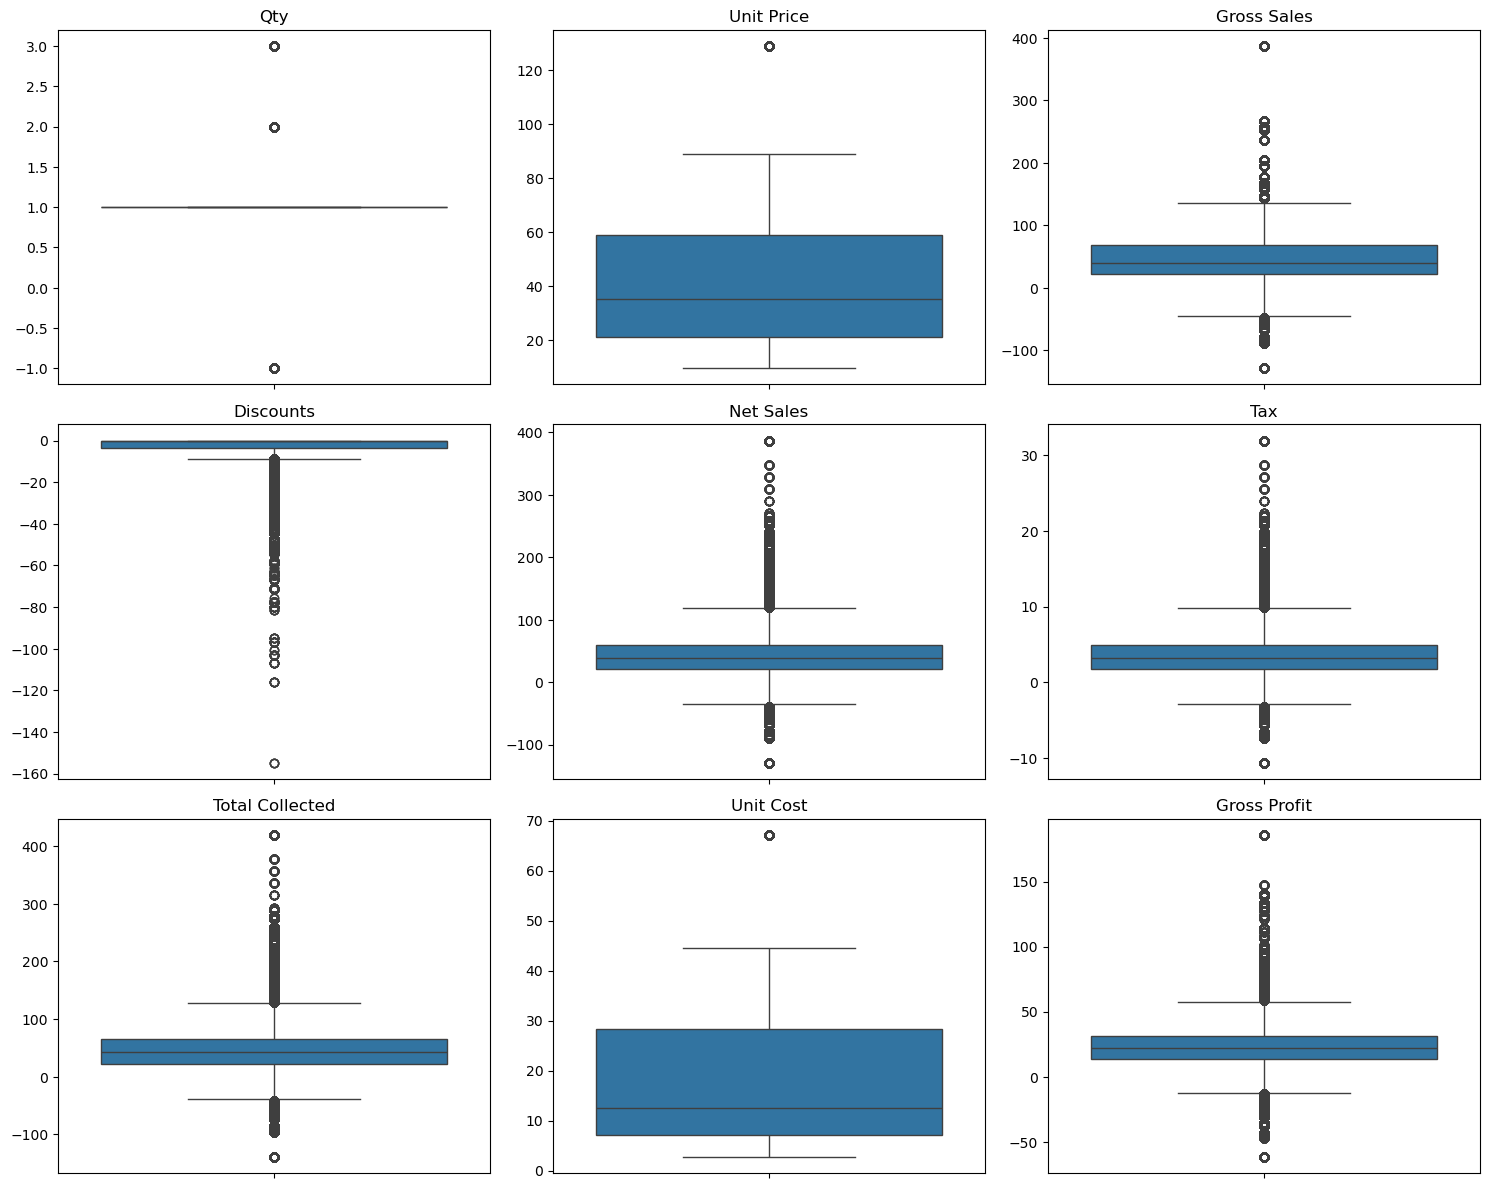

In [13]:
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows)
)

axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(
        data=df,
        y=col,
        ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")

# إخفاء الـsubplots الفاضية
for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

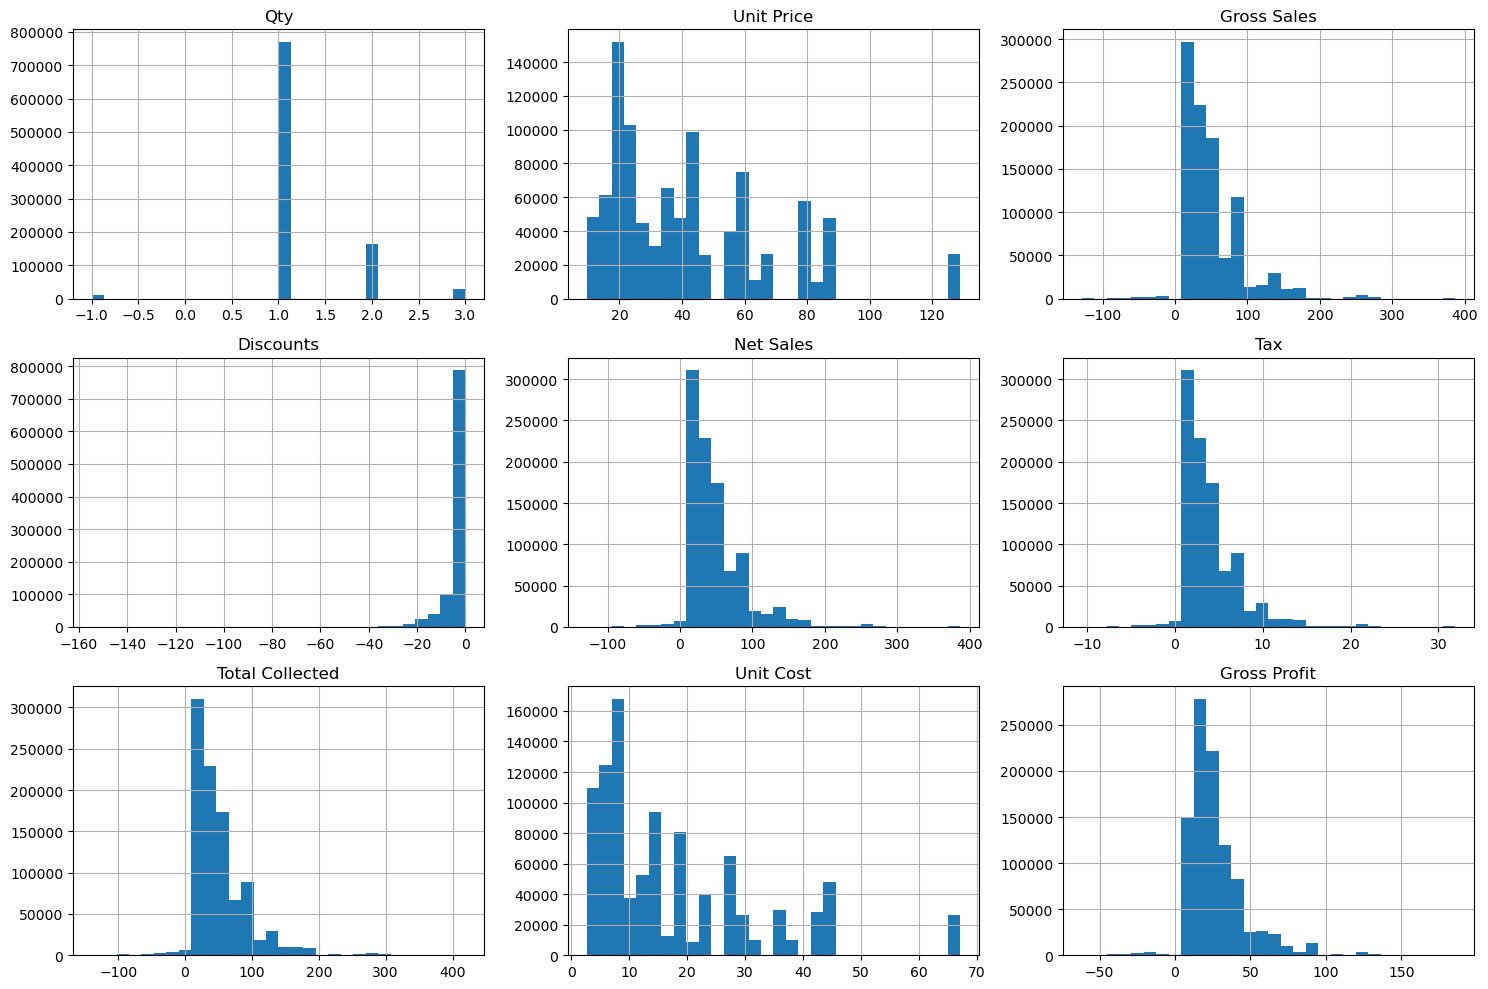

In [14]:
df[numeric_cols].hist(
    figsize=(15, 10),
    bins=30
)

plt.tight_layout()
plt.show()

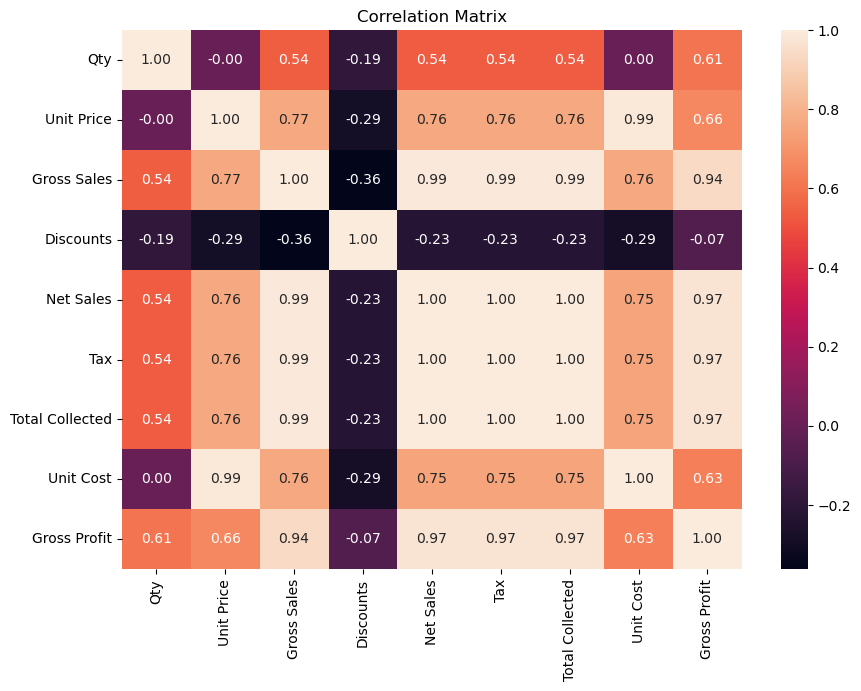

In [15]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

## Numerical EDA Findings

- Qty is highly concentrated around a single value.
- Unit Price shows a discrete/multi-modal distribution rather than a smooth continuous distribution.
- Several financial variables exhibit non-normal and multi-modal distributions.
- Discounts are heavily concentrated at zero with a negative tail.
- Negative observations are present in several financial variables.
- Gross Profit contains a substantial number of statistical outliers based on the IQR method.
- Unit Cost remains positive across the observed range.

## Feature Enginnering

In [16]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["IsWeekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)

df["Hour"] = pd.to_datetime(
    df["Time"],
    format="mixed",
    errors="coerce"
).dt.hour

In [17]:
transaction_features = (
    df.groupby("Transaction ID")
      .agg(
          Transaction_Lines=("SKU", "count"),
          Transaction_Units=("Qty", "sum"),
          Transaction_Gross_Sales=("Gross Sales", "sum"),
          Transaction_Discounts=("Discounts", "sum"),
          Transaction_Net_Sales=("Net Sales", "sum"),
          Transaction_Gross_Profit=("Gross Profit", "sum")
      )
      .reset_index()
)
transaction_features["Transaction_Discount_Rate"] = (
    -transaction_features["Transaction_Discounts"]
    / transaction_features["Transaction_Gross_Sales"]
).replace([np.inf, -np.inf], np.nan)

In [18]:
df["Has_Discount"] = (df["Discounts"] < 0).astype(int)
df["Discount_Rate"] = (
    -df["Discounts"] / df["Gross Sales"]
).replace([np.inf, -np.inf], np.nan)

In [19]:
df["Profit_Margin"] = (
    df["Gross Profit"] / df["Net Sales"]
).replace([np.inf, -np.inf], np.nan)

In [20]:
df["Total_Cost"] = df["Unit Cost"] * df["Qty"]

In [21]:
df["Has_Customer"] = df["Customer ID"].notna().astype(int)

In [22]:
df["Is_Refund"] = (
    df["Event Type"] == "Refund"
).astype(int)

In [23]:
df["Unit_Gross_Margin"] = (
    df["Unit Price"] - df["Unit Cost"]
)

df["Unit_Margin_Rate"] = (
    df["Unit_Gross_Margin"] / df["Unit Price"]
)

In [24]:
store_day = (
    df.groupby(["Location", "Date"])
      .agg(
          Gross_Sales=("Gross Sales", "sum"),
          Discounts=("Discounts", "sum"),
          Net_Sales=("Net Sales", "sum"),
          Tax=("Tax", "sum"),
          Total_Collected=("Total Collected", "sum"),
          Gross_Profit=("Gross Profit", "sum"),
          Transactions=("Transaction ID", "nunique"),
          Units=("Qty", "sum"),
          Refunds=("Is_Refund", "sum"),
          Discounted_Lines=("Has_Discount", "sum"),
          Identified_Customer_Lines=("Has_Customer", "sum")
      )
      .reset_index()
)

In [25]:
store_day

,Location,Date,Gross_Sales,Discounts,Net_Sales,Tax,Total_Collected,Gross_Profit,Transactions,Units,Refunds,Discounted_Lines,Identified_Customer_Lines
0,Store 01 - Austin,2024-01-01,456.0,-37.15,418.85,34.56,453.41,212.82,5,8,0,3,4
1,Store 01 - Austin,2024-01-02,238.0,-5.90,232.10,19.15,251.25,130.46,4,6,0,1,2
2,Store 01 - Austin,2024-01-03,296.0,-40.72,255.28,21.07,276.35,136.06,2,8,0,4,0
3,Store 01 - Austin,2024-01-04,478.0,-12.54,465.46,38.42,503.88,281.20,9,17,1,4,4
4,Store 01 - Austin,2024-01-05,902.0,-59.07,842.93,69.54,912.47,487.54,16,21,3,8,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21857,Store 30 - Kansas City,2025-12-27,8676.0,-1355.31,7320.69,603.98,7924.67,3468.03,99,187,5,84,52
21858,Store 30 - Kansas City,2025-12-28,7052.5,-1034.28,6018.22,496.56,6514.78,3036.21,81,171,4,64,36
21859,Store 30 - Kansas City,2025-12-29,3322.0,-525.95,2796.05,230.69,3026.74,1401.85,40,86,2,41,22
21860,Store 30 - Kansas City,2025-12-30,4798.5,-761.88,4036.62,333.07,4369.69,1986.27,47,109,3,52,35


In [26]:
store_day["Profit_Margin"] = (
    store_day["Gross_Profit"] / store_day["Net_Sales"]
).replace([np.inf, -np.inf], np.nan)

store_day["Discount_Rate"] = (
    -store_day["Discounts"] / store_day["Gross_Sales"]
).replace([np.inf, -np.inf], np.nan)

store_day["Refund_Rate"] = (
    store_day["Refunds"] / store_day["Transactions"]
).replace([np.inf, -np.inf], np.nan)

store_day["Avg_Transaction_Value"] = (
    store_day["Net_Sales"] / store_day["Transactions"]
).replace([np.inf, -np.inf], np.nan)

store_day["Units_Per_Transaction"] = (
    store_day["Units"] / store_day["Transactions"]
).replace([np.inf, -np.inf], np.nan)

In [27]:
df.to_csv("../../data/processed/01_square_item_sales_detail_24mo_preprocessed.csv", index=False)
